For changes in cloud properties due to pollution (CDNC, cloud fraction) as calculated from model output at ship position, this notebook will investigate the sensitivity of the change to the vertical depth over which the change considered.

In [5]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from glob import glob
import seaborn as sns
import string

# Read model output

In [7]:
apr = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,30,23,59))

simulations = {
    "ACI_OPT_2": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "ACI_OPT_2_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    }
}

wrfout_ship = []
for sim,meta in simulations.items():
    ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=apr)
    ds_sim = ds_sim.expand_dims({
        "simulation": [sim]
    })
    ds_sim = ds_sim.assign_coords({
        "pollution_state": ("simulation",[meta["pollution_state"]]),
    })
    wrfout_ship.append(ds_sim)
wrfout_ship = xr.concat(wrfout_ship, dim="simulation")
wrfout_ship["rho_air"] = wrfout_ship.wrf.density_of_dry_air[:]
wrfout_ship["air_temperature"] = wrfout_ship.wrf.air_temperature[:]
wrfout_ship["altitude"] = wrfout_ship.wrf.altitude_asl_c[:]
wrfout_ship["box_depth"] = ((wrfout_ship.wrf.altitude_asl[:]).rename({"bottom_top_stag":"bottom_top"})).diff("bottom_top")
wrfout_ship["sfc_rad"] = (wrfout_ship.SWDNB + wrfout_ship.SWUPB + wrfout_ship.LWDNB + wrfout_ship.LWUPB).mean(["i","j"])
wrfout_ship["cdnc"] = 1e-6*(wrfout_ship.QNCLOUD * wrfout_ship.rho_air).where(wrfout_ship.CLDFRA>0.1)/wrfout_ship.CLDFRA
wrfout_ship["lwp"] = 1e3*wrfout_ship.wrf.cloud_liquid_water_path[:].mean(["i","j"])


/tmp/ipykernel_1513/3451104548.py:16: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_1513/3451104548.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=a

In [8]:
def cdnc_z_mean(cdnc, z0, z1):
    return cdnc.where((cdnc.altitude>=z0)*(cdnc.altitude<z1)).mean(["bottom_top","i","j"])

def clt_z_mean(cf, z0, z1):
    return 100*cf.where((cf.altitude>=z0)*(cf.altitude<z1)).max("bottom_top").mean(["i","j"])

In [9]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


## Plot time-height profiles of CDNC, cloud fraction

In [34]:
def plot_vertical_profiles(
    time,
    height,
    x,
    time_series_range,
    simdict,
    bg,
    wai,
    mean_profile_xlim,
    ylim,
    axlabel,
    title,
):
    fig, axes = plt.subplots(2, 2, figsize=(14,6), width_ratios=[6,1])
    for i,sim in enumerate(simdict):
        # time series
        C = axes[i,0].pcolormesh(
            time,
            height.sel(simulation=sim),
            x.sel(simulation=sim),
            vmin=time_series_range[0],
            vmax=time_series_range[1],
            cmap="Greys"
        )
        axes[i,0].set_title(simdict[sim]["pollution_state"], fontsize=10, loc="right", weight="bold")
        axes[i,0].axvspan(bg.start, bg.stop, alpha=0.1, color="black")
        axes[i,0].axvline(bg.start, color="black")
        axes[i,0].axvline(bg.stop, color="black")
        axes[i,0].axvspan(wai.start, wai.stop, alpha=0.1, color="green")
        axes[i,0].axvline(wai.start, color="green")
        axes[i,0].axvline(wai.stop, color="green")
        axes[i,0].xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
        # mean profiles
        axes[i,1].plot(
            x.sel(simulation=sim,Time=bg).mean("Time"),
            height.sel(simulation=sim,Time=bg).mean("Time"),
            "k", label="background"
        )
        l1, = axes[i,1].plot(
            x.sel(simulation=sim,Time=wai).mean("Time"),
            height.sel(simulation=sim,Time=wai).mean("Time"),
            color="green",
            label="WAI"
        )
        axes[i,1].set_xlim(mean_profile_xlim)
        axes[i,1].set_yticklabels([])

    for ax in axes.flatten():
        ax.set_ylim(ylim)
        ax.axhline(y=2000, color="grey", lw=0.5)
    
    axes[-1,1].set_xlabel(axlabel)
    axes[0,0].set_xticklabels([])
    axes[0,1].legend(fontsize=10)
    plt.subplots_adjust(wspace=0.01)
    plt.colorbar(C, label=axlabel, ax=axes[:,0], shrink=0.8, pad=0.025)
    fig.suptitle(title, weight="bold", y=0.95, fontsize=18)
    return

bg = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,13,23,59))
wai = slice(dt.datetime(2020,4,15), dt.datetime(2020,4,16,23,59))
zz, tt = np.meshgrid(wrfout_ship.bottom_top, wrfout_ship.Time)
height = wrfout_ship.altitude.mean(["i","j"])

/tmp/ipykernel_1513/1351664341.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  C = axes[i,0].pcolormesh(
/tmp/ipykernel_1513/1351664341.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  C = axes[i,0].pcolormesh(


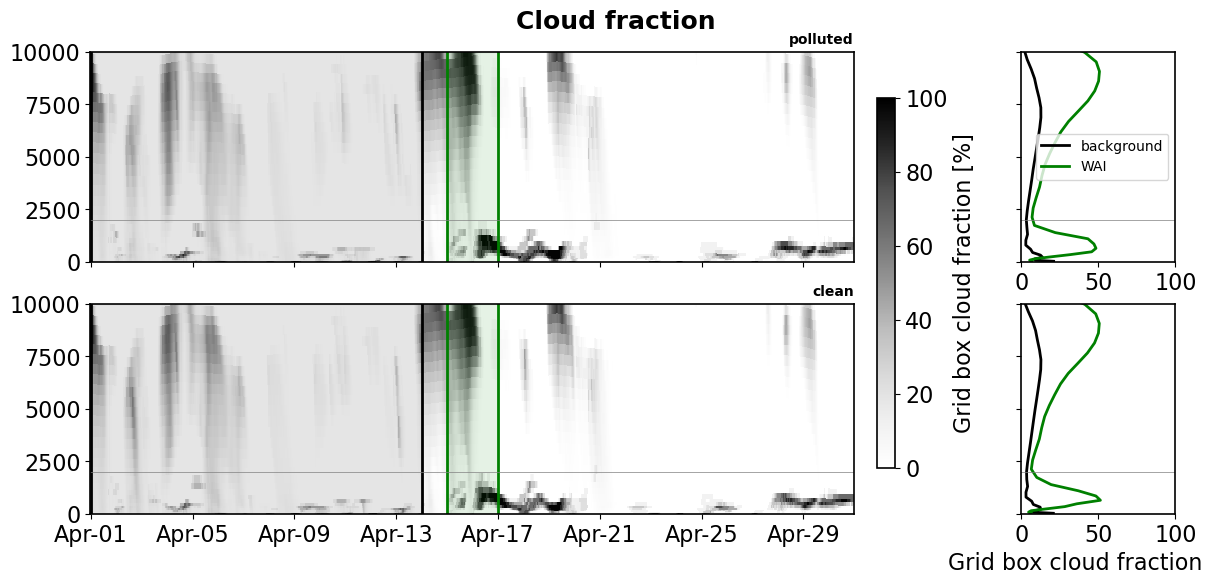

In [35]:
plot_vertical_profiles(
    tt,
    height,
    100*wrfout_ship.CLDFRA.mean(["i","j"]),
    [0,100],
    simulations,
    bg,
    wai,
    [0,100],
    [0,10000],
    "Grid box cloud fraction [%]",
    "Cloud fraction"
)

/tmp/ipykernel_1513/1351664341.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  C = axes[i,0].pcolormesh(
/tmp/ipykernel_1513/1351664341.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  C = axes[i,0].pcolormesh(


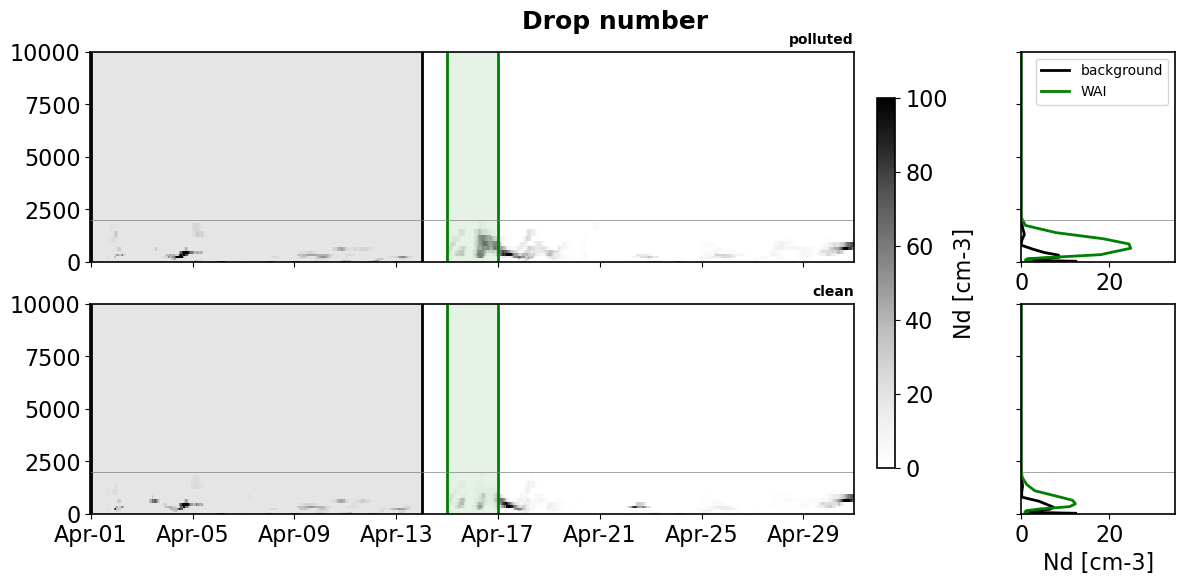

In [36]:
plot_vertical_profiles(
    tt,
    height,
    1e-6*wrfout_ship.QNCLOUD.mean(["i","j"]),
    [0,100],
    simulations,
    bg,
    wai,
    [0,35],
    [0,10000],
    "Nd [cm-3]",
    "Drop number"
)

### Process data into dataframe that plot function can read

In [13]:
bg = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,13,23,59))
wai = slice(dt.datetime(2020,4,15), dt.datetime(2020,4,16,23,59))

wai_state = []
for time in wrfout_cld.Time.values:
    time = pd.Timestamp(time)
    if time>=bg.start and time<=bg.stop:
        wai_state.append("background")
    elif time>=wai.start and time<=wai.stop:
        wai_state.append("WAI")
    else:
        wai_state.append("unclassed")
wrfout_cld = wrfout_cld.assign_coords({
    "wai_state":("Time",wai_state),
})

plot_colours = {
    "polluted": "tab:blue",
    "clean": "grey",
}

data = wrfout_cld.sel(Time=wrfout_cld.wai_state!="unclassed").to_dataframe()
stats = data.groupby(['wai_state','pollution_state']).median()


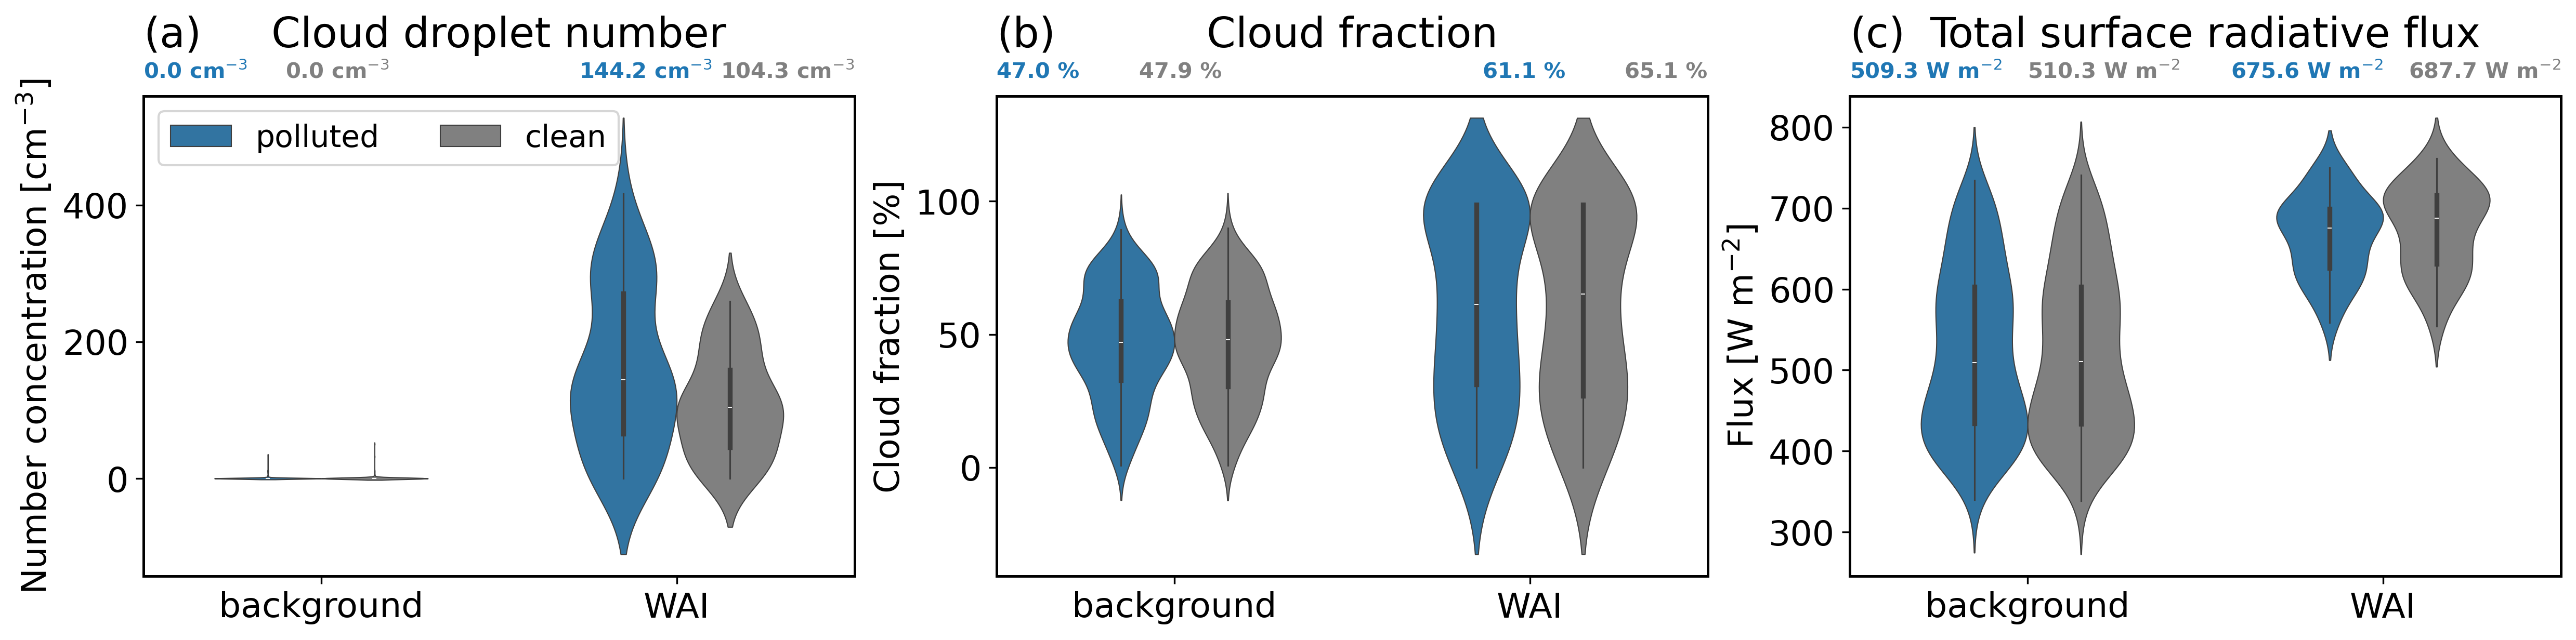

In [21]:
fs_label = 10
fig, axes = plt.subplots(1, 3, figsize=(20,4), dpi=300)

### CDNC

stats_cdnc = stats["cdnc"]
axes[0].text(
    s=f"{stats_cdnc['background']['polluted']:.1f} cm$^{{-3}}$",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[0].text(
    s=f"{stats_cdnc['background']['clean']:.1f} cm$^{{-3}}$",
    y=1.05, x=0.2, ha="left", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
axes[0].text(
    s=f"{stats_cdnc['WAI']['polluted']:.1f} cm$^{{-3}}$",
    y=1.05, x=0.8, ha="right", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[0].text(
    s=f"{stats_cdnc['WAI']['clean']:.1f} cm$^{{-3}}$",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="cdnc",
    hue="pollution_state",
    ax=axes[0],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    palette=plot_colours
)
axes[0].set_title("Cloud droplet number", y=1.075)
axes[0].set_ylabel("Number concentration [cm$^{{-3}}$]")
axes[0].set_xlabel("")

### CLOUD FRACTION

stats_cf = stats["clt_2km"]
axes[1].text(
    s=f"{stats_cf['background']['polluted']:.1f} %",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[1].text(
    s=f"{stats_cf['background']['clean']:.1f} %",
    y=1.05, x=0.2, ha="left", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
axes[1].text(
    s=f"{stats_cf['WAI']['polluted']:.1f} %",
    y=1.05, x=0.8, ha="right", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[1].text(
    s=f"{stats_cf['WAI']['clean']:.1f} %",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="clt_2km",
    hue="pollution_state",
    ax=axes[1],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    legend=False,
    palette=plot_colours,
)
axes[1].set_title("Cloud fraction", y=1.075)
axes[1].set_ylabel("Cloud fraction [%]")
axes[1].set_xlabel("")

### SURFACE RAD FLUX

stats_rad = stats["sfc_rad"]
axes[2].text(
    s=f"{stats_rad['background']['polluted']:.1f} W m$^{{-2}}$",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[2].text(
    s=f"{stats_rad['background']['clean']:.1f} W m$^{{-2}}$",
    y=1.05, x=0.25, ha="left", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
axes[2].text(
    s=f"{stats_rad['WAI']['polluted']:.1f} W m$^{{-2}}$",
    y=1.05, x=0.75, ha="right", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[2].text(
    s=f"{stats_rad['WAI']['clean']:.1f} W m$^{{-2}}$",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="sfc_rad",
    hue="pollution_state",
    ax=axes[2],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    legend=False,
    palette=plot_colours,
)
axes[2].set_title("Total surface radiative flux", y=1.075)
axes[2].set_ylabel("Flux [W m$^{{-2}}$]")
axes[2].set_xlabel("")
axes[0].legend(ncols=2, fontsize=14)
for i in range(len(axes)):
    axes[i].set_title(f"({string.ascii_lowercase[i]})", y=1.075, loc="left")
plt.savefig("figures/figureA2.png", bbox_inches="tight")